In [1]:
#Read in SAMHSA's National Survey on Drug Use and Health (NSDUH) data. 
#Read in from CSV files provided by SAMHSA for years 2023
import pandas as pd
import numpy as np

sud = pd.read_csv('mhcld_puf_2023.csv', low_memory=False)

#Display the shape of the dataframe
sud.shape

(7035641, 40)

In [2]:
sud.head()


,YEAR,AGE,EDUC,ETHNIC,RACE,SEX,SPHSERVICE,CMPSERVICE,OPISERVICE,RTCSERVICE,...,ODDFLG,PDDFLG,PERSONFLG,SCHIZOFLG,ALCSUBFLG,OTHERDISFLG,STATEFIP,DIVISION,REGION,CASEID
0,2023,4,-9,3,5,2,2,1,1,2,...,0,0,0,0,0,0,1,6,3,20230000001
1,2023,5,4,4,3,2,1,2,2,2,...,0,0,0,1,0,0,1,6,3,20230000002
2,2023,8,4,4,5,2,1,1,2,2,...,0,0,0,1,0,0,1,6,3,20230000003
3,2023,11,-9,3,5,2,2,1,2,2,...,0,0,0,0,0,1,1,6,3,20230000004
4,2023,3,3,4,5,2,1,1,2,2,...,0,0,0,0,0,0,1,6,3,20230000005


In [3]:
# Print Jsut the first 10 rows of the SUB column 
sud['SUB'].head(10)

0   -9
1   -9
2    6
3   -9
4   -9
5   -9
6   -9
7   -9
8    4
9   -9
Name: SUB, dtype: int64

In [4]:
# Drop all of the features that could lead to a data leak or are not relevant for predicting substance abuse
sud = sud.drop(columns=['ALCSUBFLG', 'SAP'])

In [5]:
# Create a binary target variable indicating substance abuse (1) or no substance abuse (0)
# If sub = -9 then Substance_Abuse = 0 all else sunstance abuse = 1
sud['Substance_Abuse'] = np.where(sud['SUB'] == -9, 0, 1)

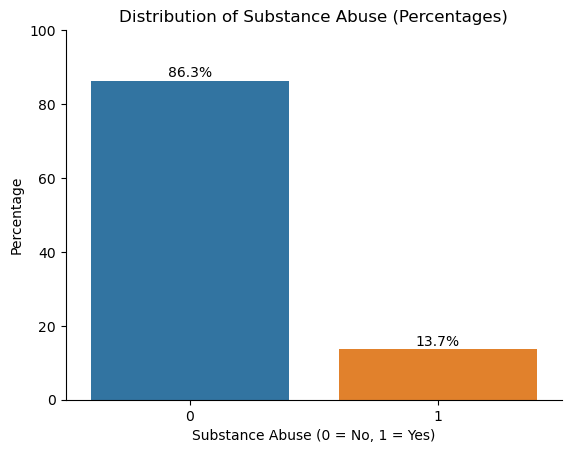

In [13]:
# Create a bar chart showing the percentages of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

counts = sud['Substance_Abuse'].value_counts(normalize=True) * 100
sns.barplot(x=counts.index, y=counts.values)
plt.title('Distribution of Substance Abuse (Percentages)')
plt.xlabel('Substance Abuse (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
# Remove top and right spines for better aesthetics
sns.despine()
plt.show()

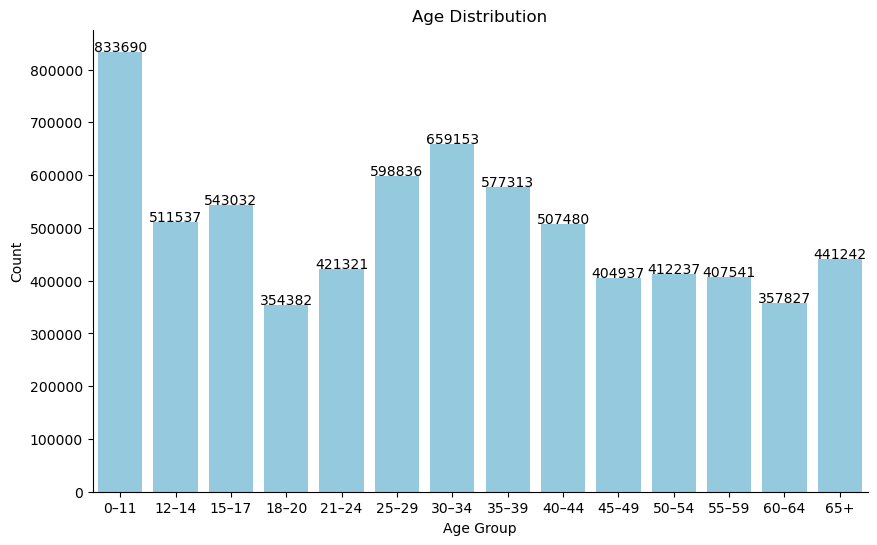

In [18]:
# Map AGE values to descriptive labels
age_map = {
    1: "0–11",
    2: "12–14",
    3: "15–17",
    4: "18–20",
    5: "21–24",
    6: "25–29",
    7: "30–34",
    8: "35–39",
    9: "40–44",
    10: "45–49",
    11: "50–54",
    12: "55–59",
    13: "60–64",
    14: "65+"
}
sud['AGE_LABEL'] = sud['AGE'].map(age_map)
age_counts = sud['AGE_LABEL'].value_counts().reindex(list(age_map.values()))
plt.figure(figsize=(10,6))
# Make all bars the same color
sns.barplot(x=age_counts.index, y=age_counts.values, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
for i, v in enumerate(age_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')
sns.despine()
plt.show()


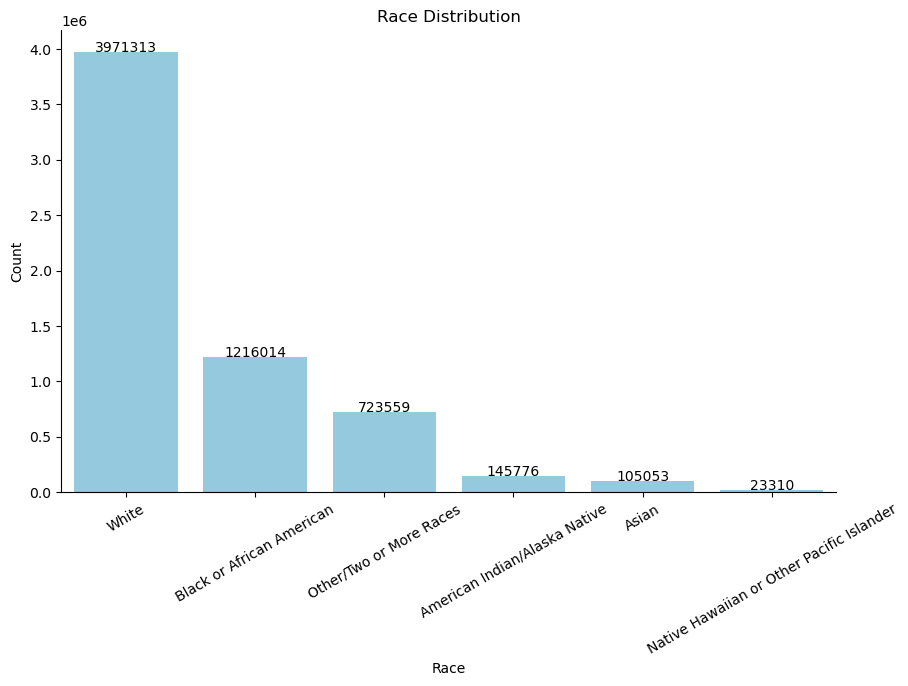

In [27]:
# Build a graph showing a distribution of race in the dataset with descriptive labels
race_map = {
    1: "American Indian/Alaska Native",
    2: "Asian",
    3: "Black or African American",
    4: "Native Hawaiian or Other Pacific Islander",
    5: "White",
    6: "Other/Two or More Races",
    -9: "Missing/Unknown"
}
sud['RACE_LABEL'] = sud['RACE'].map(race_map)

# Sort bars from tallest to shortest
race_counts = sud['RACE_LABEL'].value_counts().loc[
    ["American Indian/Alaska Native",
     "Asian",
     "Black or African American",
     "Native Hawaiian or Other Pacific Islander",
     "White",
     "Other/Two or More Races"]
].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=race_counts.index, y=race_counts.values, color='skyblue')
plt.title('Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=30)
for i, v in enumerate(race_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')
sns.despine()
plt.show()

# Begin to train model to predict substance abuse. 

In [28]:
# Copy the df to train a model
model_df = sud.copy()

In [43]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['SUB', 'Substance_Abuse', 'MH1', 'MH2', 'MH3', 'CASEID']) 

#Get dummies for categorical variables
features = pd.get_dummies(features, drop_first=True)
target = model_df['Substance_Abuse']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_train = le.fit_transform(target_train)
target_test = le.transform(target_test)

In [44]:
# Chcek for missing values 

import numpy as np

# Check for NaNs in features_train
print("NaNs in features_train:", np.isnan(features_train).sum().sum())
print("NaNs in features_test:", np.isnan(features_test).sum().sum())

# Impute if any NaNs exist
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
features_train = imputer.fit_transform(features_train)
features_test = imputer.transform(features_test)


NaNs in features_train: 0
NaNs in features_test: 0


In [46]:
# Train multiple classification models with hyperparameter tuning using GridSearchCV
# Train logistic regression, decision tree, random forest, gradient boosted trees as well as an MLP neural network. 
# Evaluate on F2 score.
# Supress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, fbeta_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Logistic Regression Grid Search
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy')
lr_grid.fit(features_train, target_train)
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(features_test)
lr_acc = accuracy_score(target_test, lr_pred)
lr_f2 = fbeta_score(target_test, lr_pred, beta=2)
print(f"Best Logistic Regression Accuracy: {lr_acc:.3f}, F2 Score: {lr_f2:.3f}")

# Decision Tree Grid Search
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=3, scoring='accuracy')
dt_grid.fit(features_train, target_train)
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(features_test)
dt_acc = accuracy_score(target_test, dt_pred)
dt_f2 = fbeta_score(target_test, dt_pred, beta=2)
print(f"Best Decision Tree Accuracy: {dt_acc:.3f}, F2 Score: {dt_f2:.3f}")

# Random Forest Grid Search
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy')
rf_grid.fit(features_train, target_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(features_test)
rf_acc = accuracy_score(target_test, rf_pred)
rf_f2 = fbeta_score(target_test, rf_pred, beta=2)
print(f"Best Random Forest Accuracy: {rf_acc:.3f}, F2 Score: {rf_f2:.3f}")

# XGBoost Grid Search
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy')
xgb_grid.fit(features_train, target_train)
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(features_test)
xgb_acc = accuracy_score(target_test, xgb_pred)
xgb_f2 = fbeta_score(target_test, xgb_pred, beta=2)
print(f"Best XGBoost Accuracy: {xgb_acc:.3f}, F2 Score: {xgb_f2:.3f}")

# MLPClassifier (Neural Network) Grid Search
mlp_params = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=3, scoring='accuracy')
mlp_grid.fit(features_train, target_train)
mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(features_test)
mlp_acc = accuracy_score(target_test, mlp_pred)
mlp_f2 = fbeta_score(target_test, mlp_pred, beta=2)
print(f"Best MLPClassifier Accuracy: {mlp_acc:.3f}, F2 Score: {mlp_f2:.3f}")

# Select best model by F2 Score
f2_scores = {
    'Logistic Regression': lr_f2,
    'Decision Tree': dt_f2,
    'Random Forest': rf_f2,
    'XGBoost': xgb_f2,
    'MLPClassifier': mlp_f2
}
best_f2_model = max(f2_scores, key=f2_scores.get)
print(f"Best model by F2 Score: {best_f2_model} with F2 Score {f2_scores[best_f2_model]:.3f}")

Best Logistic Regression Accuracy: 0.891, F2 Score: 0.356
Best Decision Tree Accuracy: 0.901, F2 Score: 0.551
Best Random Forest Accuracy: 0.903, F2 Score: 0.546
Best XGBoost Accuracy: 0.915, F2 Score: 0.550
Best MLPClassifier Accuracy: 0.904, F2 Score: 0.435
Best model by F2 Score: Decision Tree with F2 Score 0.551


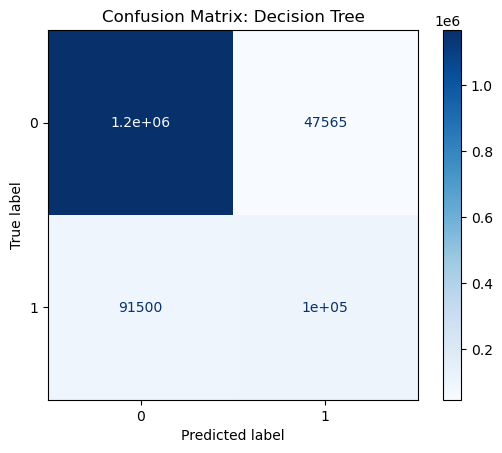

Confusion Matrix Values:
[[1166674   47565]
 [  91500  101390]]


In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions for the best model by F2 score
if best_f2_model == 'Logistic Regression':
    best_pred = lr_pred
elif best_f2_model == 'Decision Tree':
    best_pred = dt_pred
elif best_f2_model == 'Random Forest':
    best_pred = rf_pred
elif best_f2_model == 'XGBoost':
    best_pred = xgb_pred
elif best_f2_model == 'MLPClassifier':
    best_pred = mlp_pred

# Build and display confusion matrix
cm = confusion_matrix(target_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {best_f2_model}')
plt.show()

# Print actual confusion matrix values (no scientific notation)
np.set_printoptions(suppress=True)
print("Confusion Matrix Values:")
print(cm)


In [48]:
# How many nodes are in the best decision tree model?
from sklearn import tree
if best_f2_model == 'Decision Tree':
    num_nodes = dt_best.tree_.node_count
    print(f"Number of nodes in the best Decision Tree model: {num_nodes}")

Number of nodes in the best Decision Tree model: 636797


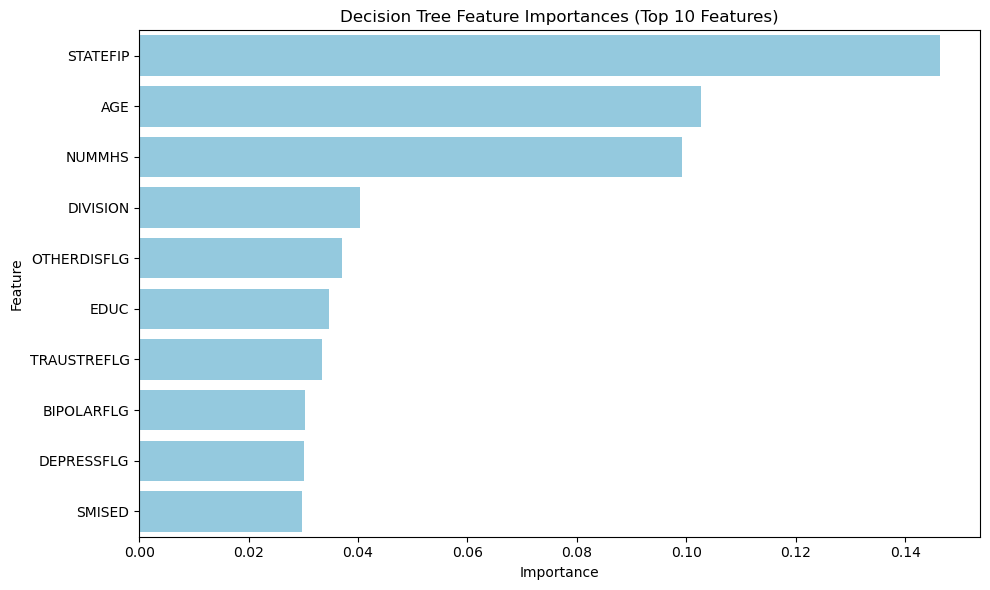

In [52]:
# Visualize feature importances for the best model if it's a decision tree
# Only show the top 10 features
# Make all bars the same color

if best_f2_model == 'Decision Tree':
    importances = dt_best.feature_importances_
    feature_names = features.columns
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(10,6))
    sns.barplot(x=importances[indices], y=feature_names[indices], color='skyblue')
    plt.title('Decision Tree Feature Importances (Top 10 Features)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()